In [ ]:
import pandas as pd
import random
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel, BertConfig, BertModel
# import adapters
# from adapters import AutoAdapterModel
import gc
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib

import pickle
import time
import memory_profiler

%load_ext memory_profiler

from pathlib import Path
import distro

%load_ext watermark

In [ ]:
%load_ext IPython.extensions.autoreload
%autoreload 2

from text_visualizations.plotting import plot_tsne_colors

In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures/tmp")
data_path = Path("../data")

In [ ]:
plt.style.use("matplotlib_style.txt")

In [ ]:
%watermark -t -d -tz -u -v -iv -w -m -h -p transformers -p openTSNE
print(distro.name(pretty=True))

Last updated: 2025-04-09 10:38:52CEST

Python implementation: CPython
Python version       : 3.12.1
IPython version      : 9.0.2

openTSNE: not installed

Compiler    : GCC 8.5.0 20210514 (Red Hat 8.5.0-21)
OS          : Linux
Release     : 4.18.0-553.el8_10.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

Hostname: gber7

matplotlib         : 3.10.1
torch              : 2.6.0
black              : 25.1.0
sklearn            : 1.6.1
transformers       : 4.50.2
numpy              : 2.1.3
pathlib            : 1.0.1
memory_profiler    : 0.61.0
pandas             : 2.2.3
distro             : 1.9.0
text_visualizations: 0.1.0
jupyter_black      : 0.4.0

Watermark: 2.5.0

Rocky Linux 8.10 (Green Obsidian)


# Imports (general)

In [ ]:
%%time
iclr = pd.read_parquet(
    data_path / "iclr25v2.parquet",
    engine="fastparquet",  # "pyarrow",
)

CPU times: user 173 ms, sys: 87.3 ms, total: 260 ms
Wall time: 787 ms


In [ ]:
pickle_in = open(
    data_path / "dict_label_to_color.pkl",
    "rb",
)
dict_label_to_color = pickle.load(pickle_in)

In [ ]:
colors_iclr = np.vectorize(dict_label_to_color.get)(iclr.labels)

# Analysis

## Exp001

### Import results

In [ ]:
saving_path = Path("sbert/iclr/exp001_20250404")

df_log_training = pd.read_parquet(
    variables_path / saving_path / "df_log_training",
    # engine="fastparquet",
)
embeddings_2d = np.load(variables_path / saving_path / "embeddings_2d.npy")

In [ ]:
embeddings_2d.shape

(34524, 2)

In [ ]:
df_log_training

,epoch,loss,knn
0,0,3.772388,0.133333
1,1,3.590255,0.152910
2,2,3.554534,0.157672
3,3,3.538906,0.164550
4,4,3.513409,0.154497
5,5,3.506853,0.166138
6,6,3.500837,0.154497
7,7,3.483728,0.162963
8,8,3.474757,0.152910
9,9,3.478869,0.155556


### Plots

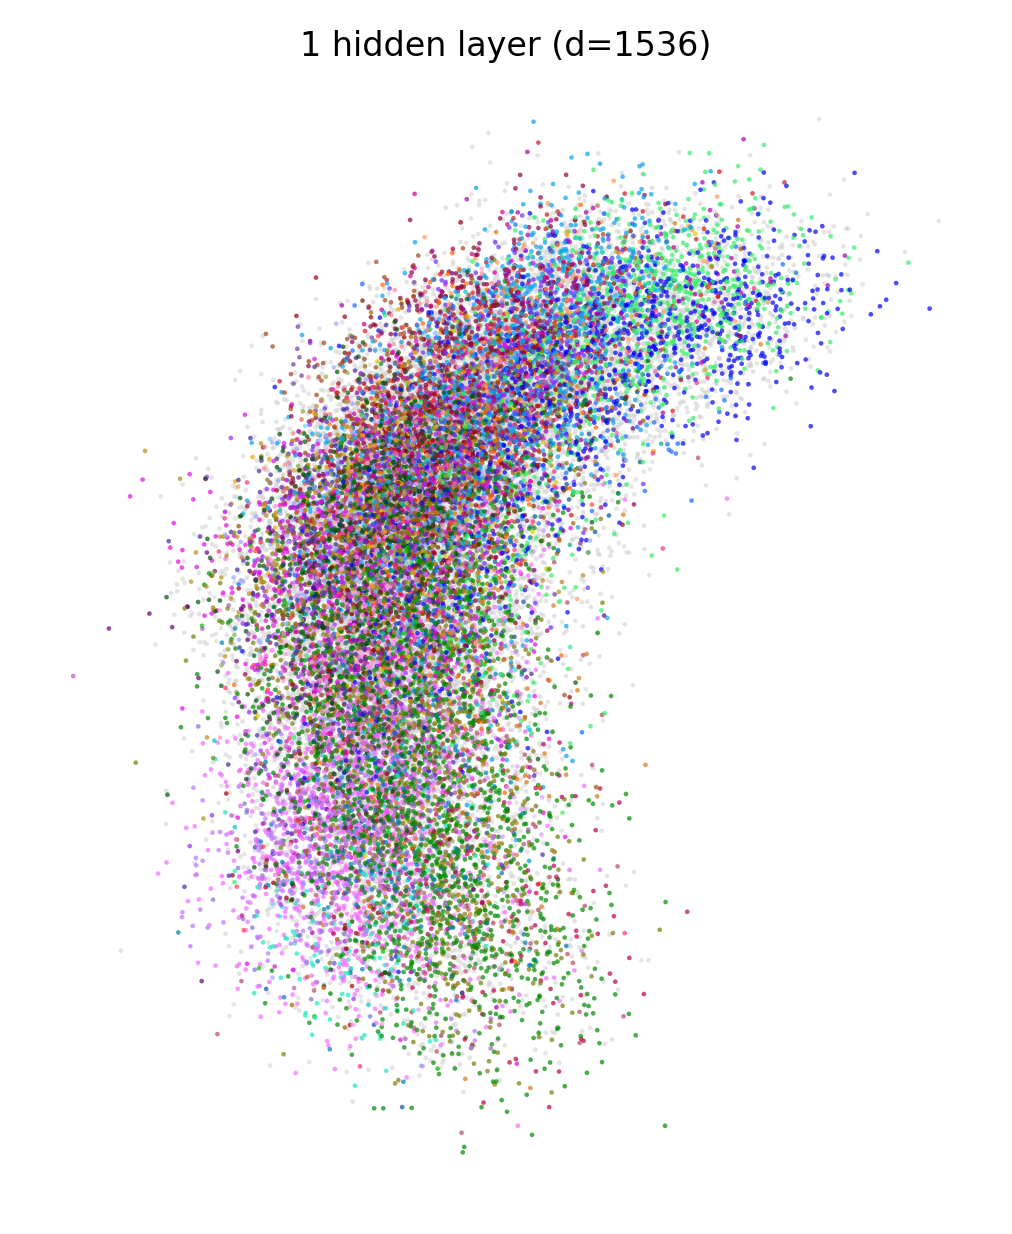

In [ ]:
fig, ax = plot_tsne_colors(embeddings_2d, colors_iclr, figsize=(4, 4))
ax.set_title("1 hidden layer (d=1536)")
fig.savefig(figures_path / "embedding_exp001_v1.png")

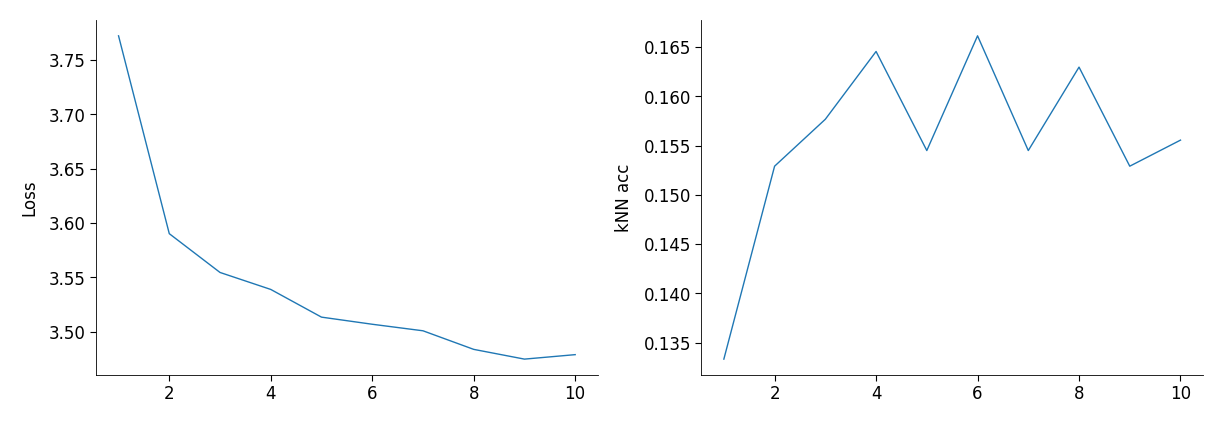

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2), dpi=200, layout="constrained")

ax[0].plot(df_log_training.epoch + 1, df_log_training.loss)
ax[0].set_ylabel("Loss")
ax[1].plot(df_log_training.epoch + 1, df_log_training.knn)
ax[1].set_ylabel("kNN acc")

fig.savefig(figures_path / "loss_and_knn_acc_vs_epochs_exp001_v1.png")

## Exp002

### Import results

In [ ]:
exp_name = "exp002"
saving_path = Path("sbert/iclr/exp002_20250407")

df_log_training = pd.read_parquet(
    variables_path / saving_path / "df_log_training",
    # engine="fastparquet",
)
embeddings_2d = np.load(variables_path / saving_path / "embeddings_2d.npy")

In [ ]:
embeddings_2d.shape

(34524, 2)

In [ ]:
df_log_training

,epoch,loss,knn
0,0,3.656072,0.175661
1,1,3.556590,0.193651
2,2,3.523716,0.180952
3,3,3.507209,0.189947
4,4,3.484339,0.203704
5,5,3.453743,0.192063
6,6,3.450215,0.194180
7,7,3.428980,0.192593
8,8,3.423496,0.203704
9,9,3.416111,0.202116


### Plots

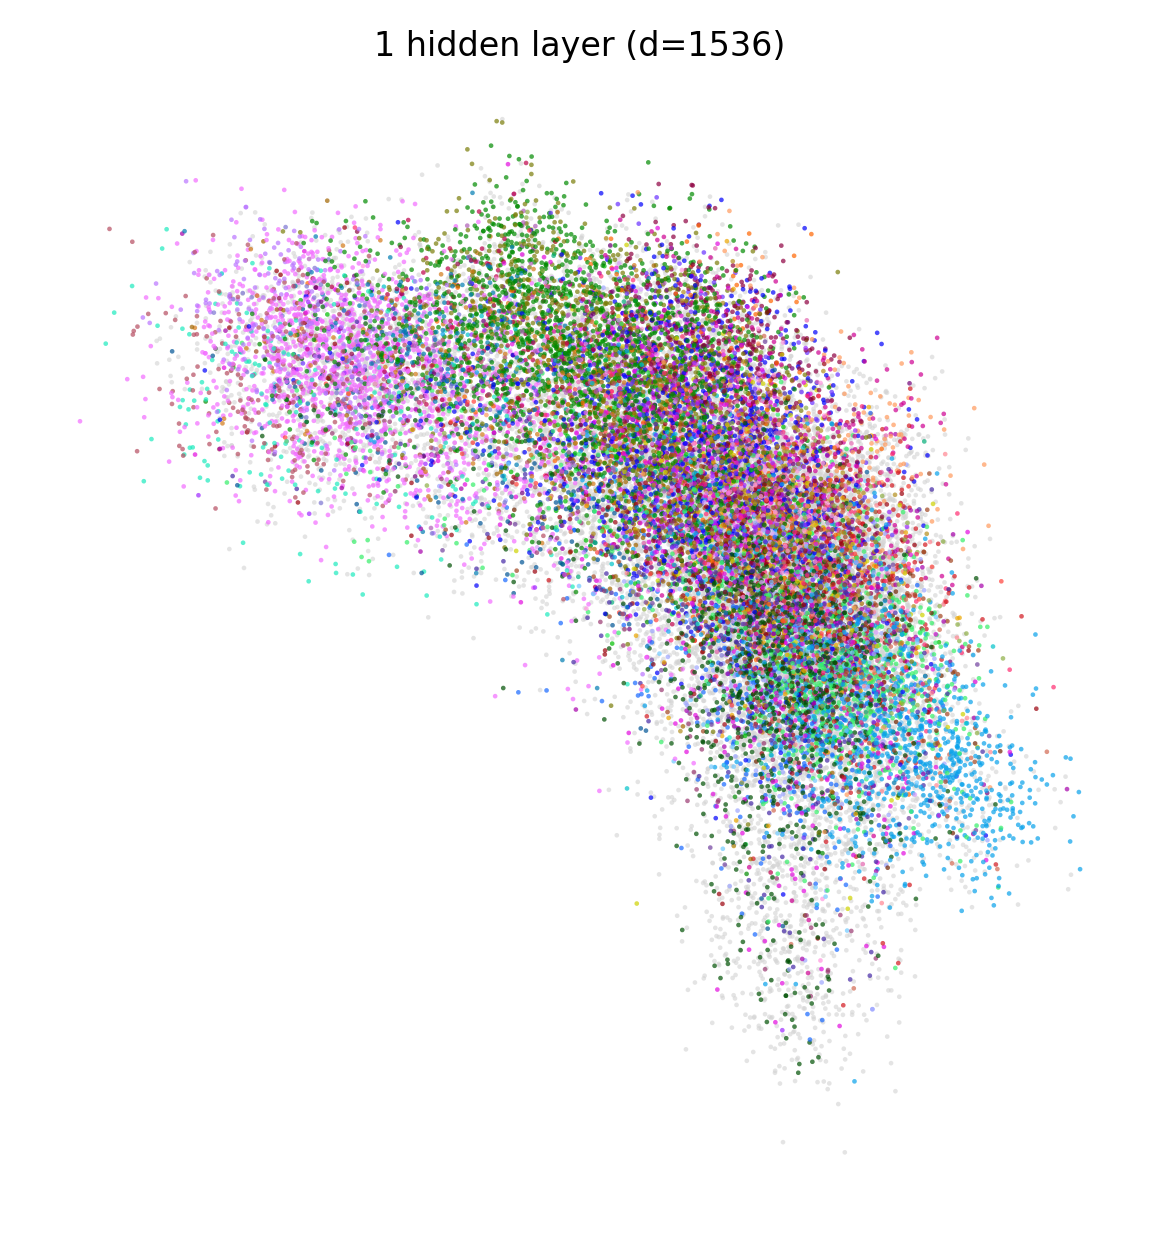

In [ ]:
fig, ax = plot_tsne_colors(embeddings_2d, colors_iclr, figsize=(4, 4))
ax.set_title("1 hidden layer (d=1536)")
fig.savefig(figures_path / f"embedding_{exp_name}_v1.png")

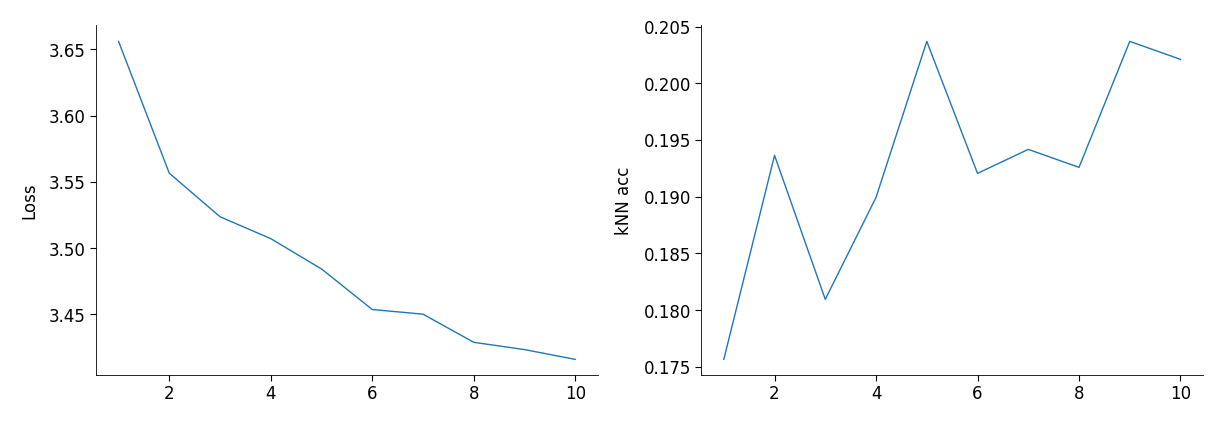

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2), dpi=200, layout="constrained")

ax[0].plot(df_log_training.epoch + 1, df_log_training.loss)
ax[0].set_ylabel("Loss")
ax[1].plot(df_log_training.epoch + 1, df_log_training.knn)
ax[1].set_ylabel("kNN acc")

fig.savefig(figures_path / f"loss_and_knn_acc_vs_epochs_{exp_name}_v1.png")

## Exp003

### Import results

In [ ]:
exp_name = "exp003"
saving_path = Path("sbert/iclr/exp003_20250408")

# df_log_training = pd.read_hdf(
#     variables_path / saving_path / "training_eval_results.h5"
# )
# df_log_training["knn"] = [elem[0] for elem in df_log_training["knn"].to_list()]


df_log_training = pd.read_parquet(
    variables_path / saving_path / "df_log_training",
    # engine="fastparquet",
)
losses = np.load(variables_path / saving_path / "losses.npy")
embeddings_2d = np.load(variables_path / saving_path / "embeddings_2d.npy")

In [ ]:
embeddings_2d.shape

(34524, 2)

In [ ]:
df_log_training

,epoch,loss,knn
0,0,3.655686,0.174603
1,50,2.957107,0.229101
2,100,2.709281,0.232804
3,150,2.560188,0.234921
4,200,2.450751,0.247090
5,249,2.406423,0.239153


### Plots

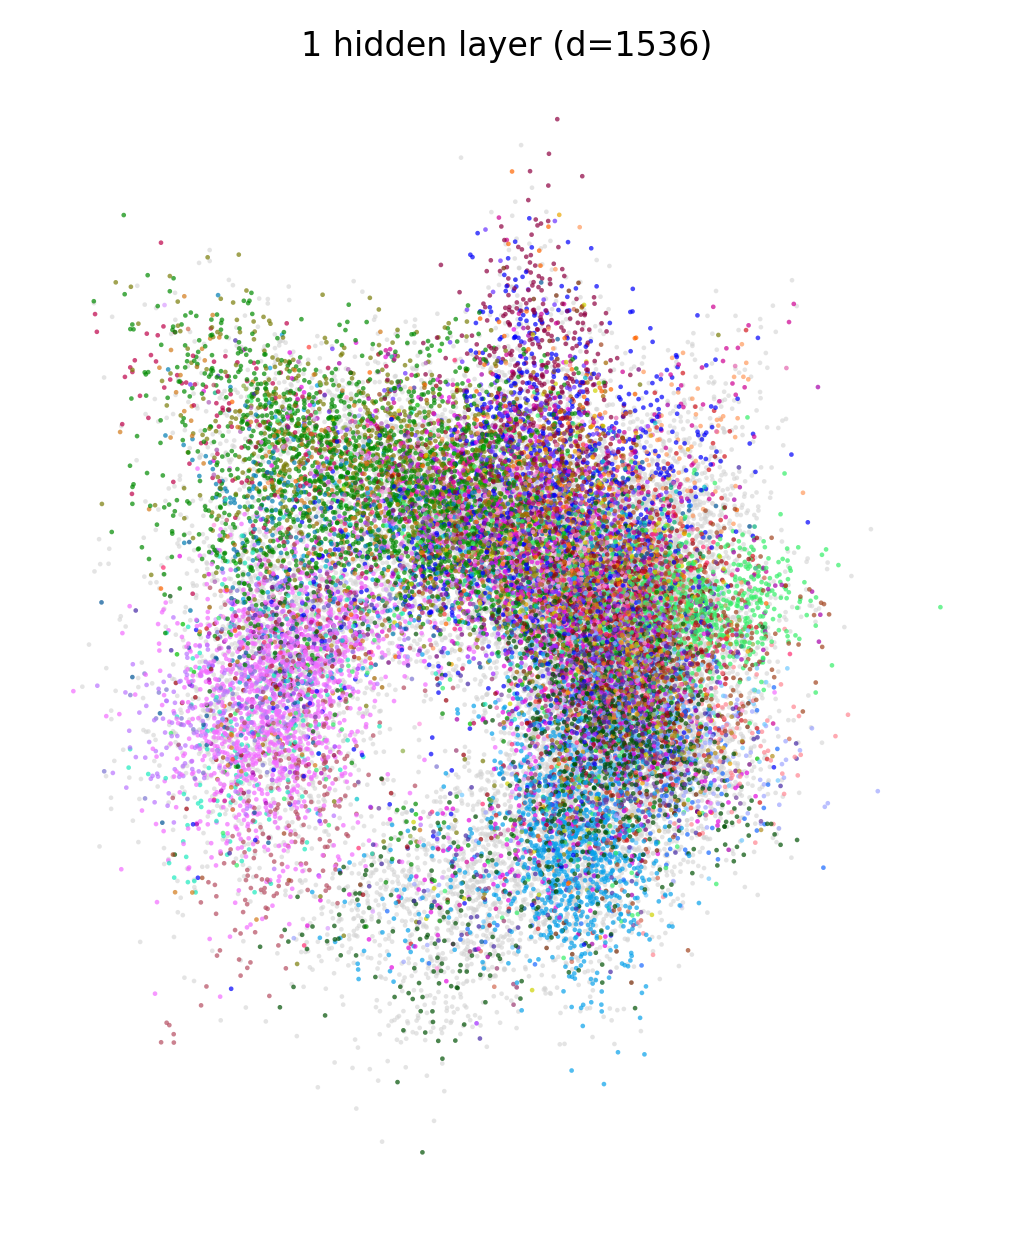

In [ ]:
fig, ax = plot_tsne_colors(embeddings_2d, colors_iclr, figsize=(4, 4))
ax.set_title("1 hidden layer (d=1536)")
fig.savefig(figures_path / f"embedding_{exp_name}_v1.png")

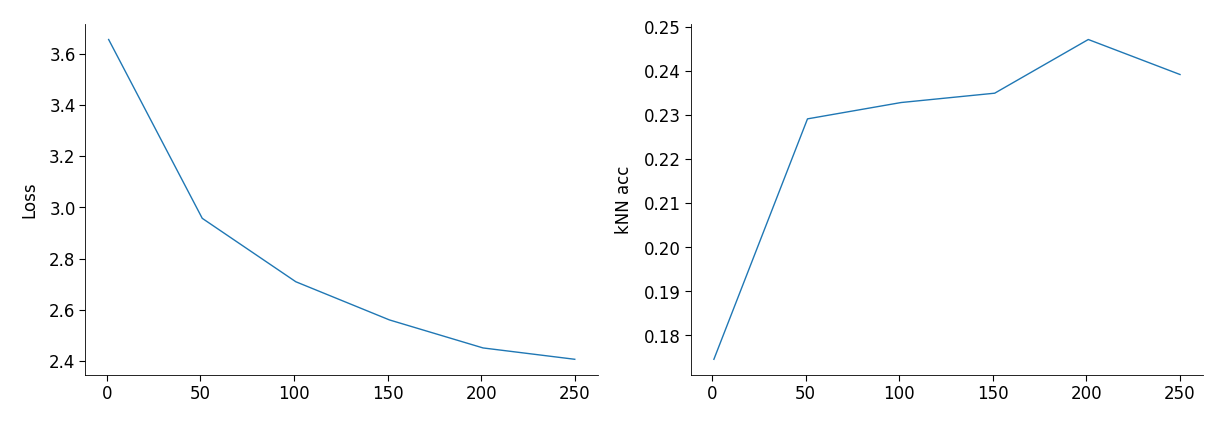

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2), dpi=200, layout="constrained")

ax[0].plot(df_log_training.epoch + 1, df_log_training.loss)
ax[0].set_ylabel("Loss")
ax[1].plot(df_log_training.epoch + 1, df_log_training.knn)
ax[1].set_ylabel("kNN acc")

fig.savefig(figures_path / f"loss_and_knn_acc_vs_epochs_{exp_name}_v1.png")